In [7]:
import pandas as pd

# Read the original dataset
df = pd.read_csv(r"C:\Users\ACER\Downloads\archive\Sales Transaction v.4a.csv")

# Save a duplicate copy
df.to_csv(
    r"C:\Users\ACER\Downloads\archive\Sales_Transaction_Copy.csv",
    index=False
)

print("Duplicate copy created successfully!")

Duplicate copy created successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv(r"C:\Users\ACER\Downloads\archive\Sales_Transaction_Copy.csv")
df.head()
df.tail()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany
536349,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.45,-2,12472.0,Germany


In [ ]:
df.columns

Index(['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price',
       'Quantity', 'CustomerNo', 'Country'],
      dtype='str')

In [ ]:
df.dtypes

TransactionNo        str
Date                 str
ProductNo            str
ProductName          str
Price            float64
Quantity           int64
CustomerNo       float64
Country              str
dtype: object

In [ ]:
df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


In [ ]:
df.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [ ]:
df = df.dropna()

print(df.isnull().sum())

TransactionNo    0
Date             0
ProductNo        0
ProductName      0
Price            0
Quantity         0
CustomerNo       0
Country          0
dtype: int64


In [ ]:
df.duplicated().sum()

np.int64(5200)

In [ ]:
df = df.drop_duplicates()

print(df.duplicated().sum())

0


In [ ]:
print("Total Customers:", df["CustomerNo"].nunique())

Total Customers: 4738


In [ ]:
print("Total Products:", df["ProductName"].nunique())

Total Products: 3767


In [ ]:
print("Total Orders:", len(df))

Total Orders: 531095


In [ ]:
print("Average Quantity:", df["Quantity"].mean())

Average Quantity: 9.993146235607565


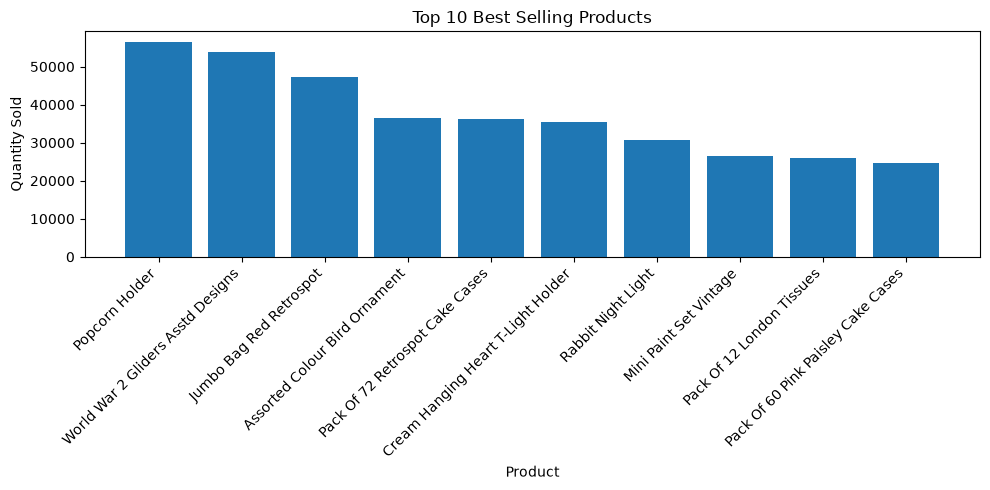

In [ ]:
top_products = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_products.index, top_products.values)

plt.title("Top 10 Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

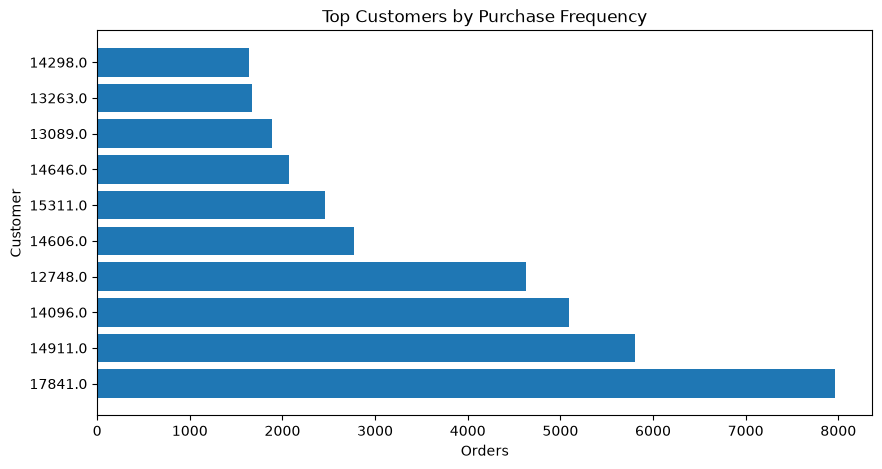

In [ ]:
customer_orders = df["CustomerNo"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.barh(customer_orders.index.astype(str), customer_orders.values)

plt.title("Top Customers by Purchase Frequency")
plt.xlabel("Orders")
plt.ylabel("Customer")

plt.show()

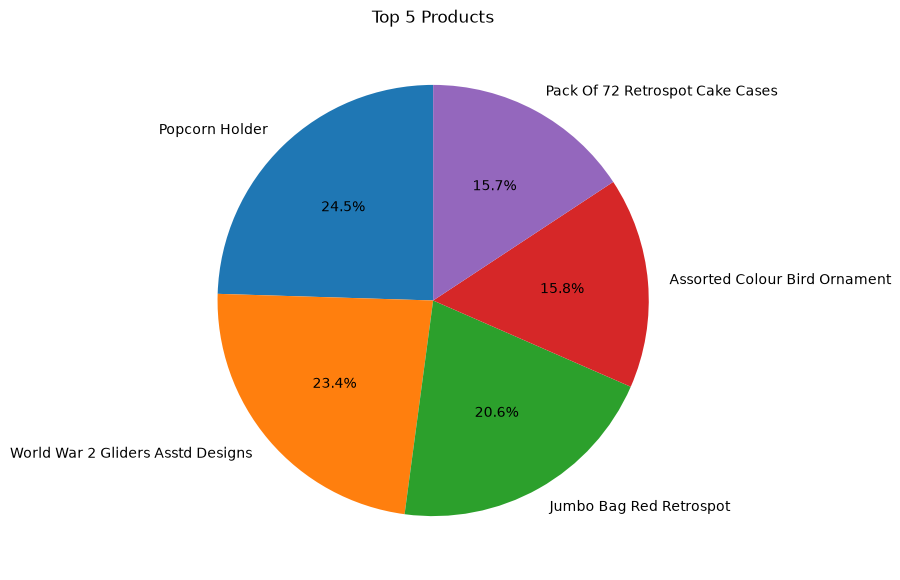

In [ ]:
top5 = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,7))
plt.pie(top5, labels=top5.index, autopct="%1.1f%%", startangle=90)

plt.title("Top 5 Products")

plt.show()

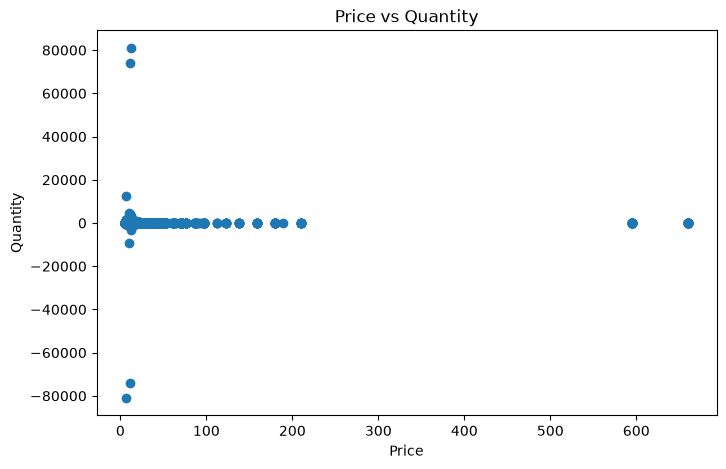

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Price"], df["Quantity"])

plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")

plt.show()

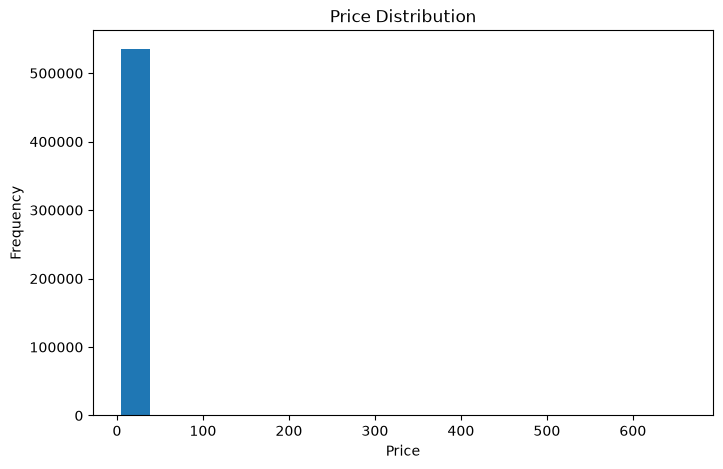

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(df["Price"], bins=20)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

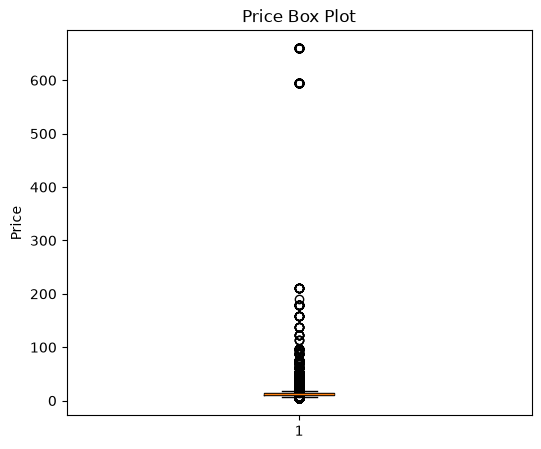

In [ ]:
plt.figure(figsize=(6,5))

plt.boxplot(df["Price"])

plt.title("Price Box Plot")
plt.ylabel("Price")

plt.show()

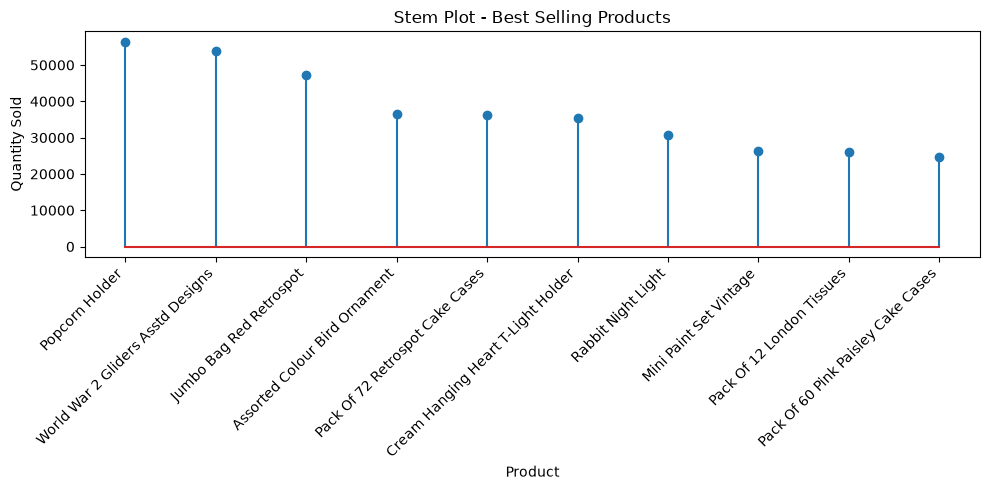

In [ ]:
top_products = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.stem(range(len(top_products)), top_products.values)

plt.xticks(range(len(top_products)), top_products.index, rotation=45, ha="right")

plt.title("Stem Plot - Best Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.tight_layout()
plt.show()

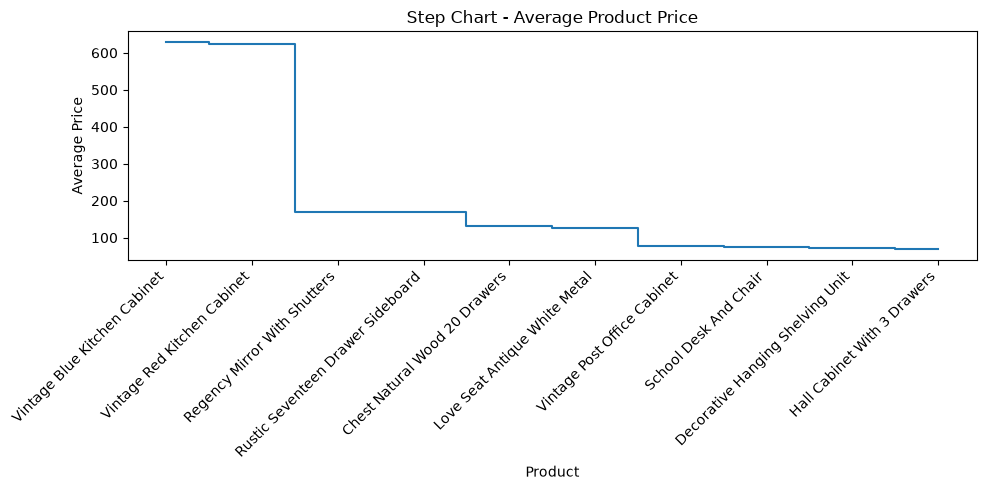

In [ ]:
price_compare = df.groupby("ProductName")["Price"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.step(range(len(price_compare)), price_compare.values, where="mid")

plt.xticks(range(len(price_compare)), price_compare.index, rotation=45, ha="right")

plt.title("Step Chart - Average Product Price")
plt.xlabel("Product")
plt.ylabel("Average Price")

plt.tight_layout()
plt.show()

In [16]:
monthly_sales = (
    df.groupby(df["Date"].dt.to_period("M"))
      .agg({"Revenue": "sum"})
      .reset_index()
)

monthly_sales["Date"] = monthly_sales["Date"].astype(str)

monthly_sales

,Date,Revenue
0,2018-12,4234147.48
1,2019-01,3649506.42
2,2019-02,3299537.56
3,2019-03,4353308.78
4,2019-04,3416109.24
5,2019-05,4530850.36
6,2019-06,4410422.29
7,2019-07,4518347.92
8,2019-08,4614243.55
9,2019-09,6542706.30


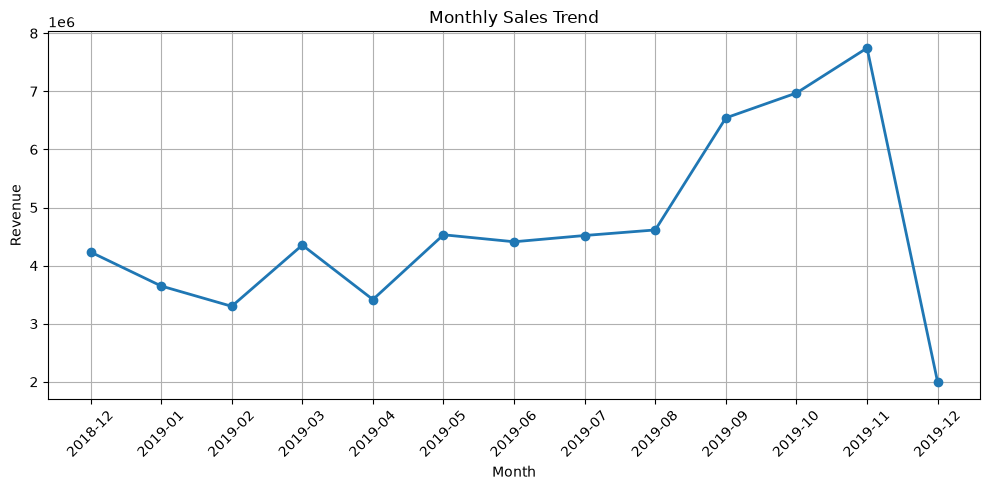

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()